# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

En este notebook se entrenan 4 modelos para predecir el peso de los pollos: Support Vector Regressor, Random Forest Regressor, K Nearest Neighbors y Multilayer Perceptron.

Se utilizan 2 Componentes Principales del Dataset

In [1]:
# Librerias
import numpy as np
import pandas as pd
import time

import optuna

from IPython.display import clear_output

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import sklearn.model_selection

import joblib

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Código

In [2]:
# Cargar datos
datos1 = pd.read_excel('./misDatos.xlsx', sheet_name = 'X_train')
datos2 = pd.read_excel('./misDatos.xlsx', sheet_name = 'X_test')

fil, col = datos1.shape

X_train = datos1.iloc[:, 0 : col - 1].to_numpy()
Y_train = datos1.iloc[:, col - 1].to_numpy()

X_test = datos2.iloc[:, 0 : col - 1].to_numpy()
Y_test = datos2.iloc[:, col - 1].to_numpy()

In [3]:
# Cargar datos de estandarización y PCA
scx = joblib.load('T_scaler8.pkl')
pca = joblib.load('T_PCA2.pkl')

In [4]:
# Estandarizar los datos
X_train_std = scx.transform(X_train)
X_test_std = scx.transform(X_test)

X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print(X_train_std.shape)
print(X_train_pca.shape)

(2439, 8)
(2439, 2)


## Support Vector Regressor

In [5]:
# Entrenamiento de modelo
svr = joblib.load('./modelo_svr_pca2.pkl')

inicio = time.time()
svr.fit(X_train_pca, Y_train)
fin = time.time()

print('Tiempo de entrenamiento: ', round(fin - inicio, 3), 's')

Tiempo de entrenamiento:  0.156 s


In [6]:
# Predecir datos
inicio = time.time()
Y_pred_train = svr.predict(X_train_pca)
Y_pred_test = svr.predict(X_test_pca)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.182 s


In [7]:
# Métricas de evaluación
E = mean_squared_error(Y_train, Y_pred_train)
r2 = r2_score(Y_train, Y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.037
R2:  0.65
Datos de test
Error cuadrático medio:  0.052
R2:  0.51


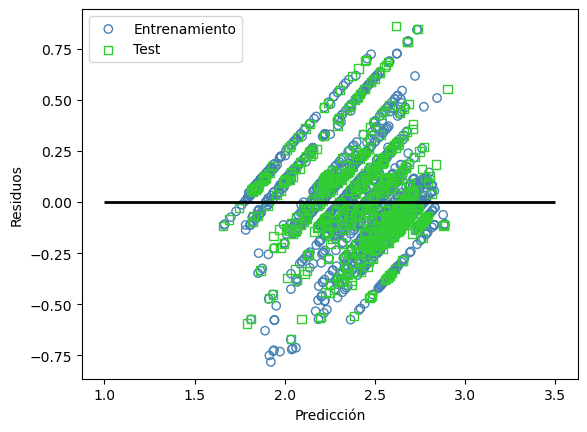

In [8]:
# Graficar datos
plt.scatter(Y_pred_train, Y_pred_train - Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_pred_test, Y_pred_test - Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

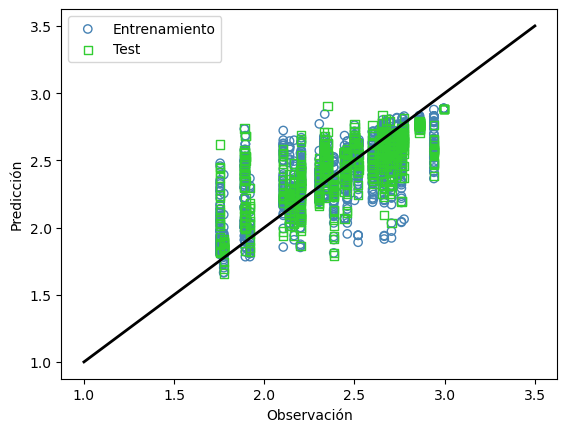

In [9]:
# Graficar datos
plt.scatter(Y_train, Y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_test, Y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color='black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()

## Random Forest Regressor

In [10]:
# Entrenamiento de modelo
rf = joblib.load('./modelo_rf_pca2.pkl')

inicio = time.time()
rf.fit(X_train_pca, Y_train)
fin = time.time()

print('Tiempo de entrenamiento: ', round(fin - inicio, 3), 's')

Tiempo de entrenamiento:  1.557 s


In [11]:
# Predecir datos
inicio = time.time()
Y_pred_train = rf.predict(X_train_pca)
Y_pred_test = rf.predict(X_test_pca)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.175 s


In [12]:
# Métricas de evaluación
E = mean_squared_error(Y_train, Y_pred_train)
r2 = r2_score(Y_train, Y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.006
R2:  0.95
Datos de test
Error cuadrático medio:  0.04
R2:  0.63


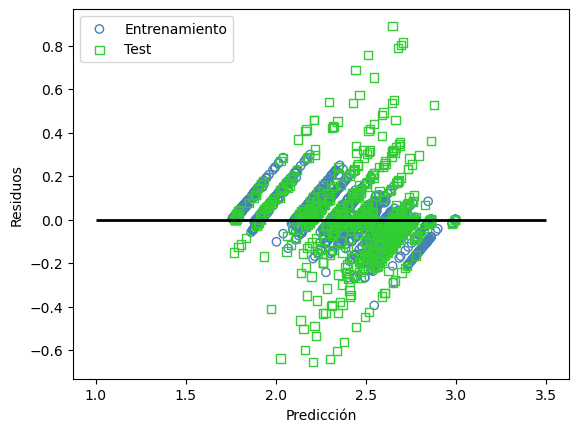

In [13]:
# Graficar datos
plt.scatter(Y_pred_train, Y_pred_train - Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_pred_test, Y_pred_test - Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

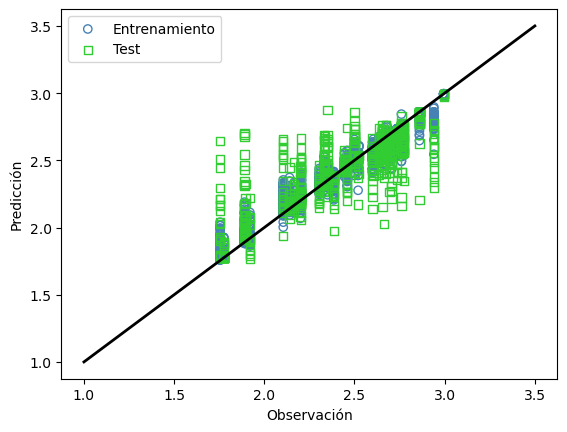

In [14]:
# Graficar datos
plt.scatter(Y_train, Y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_test, Y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color='black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()

## K Neighbors Regressor

In [15]:
# Entrenamiento de modelo
knn = joblib.load('./modelo_knn_pca2.pkl')

inicio = time.time()
knn.fit(X_train_pca, Y_train)
fin = time.time()

print('Tiempo de entrenamiento: ', round(fin - inicio, 3), 's')

Tiempo de entrenamiento:  0.002 s


In [16]:
# Predecir datos
inicio = time.time()

Y_pred_train = knn.predict(X_train_pca)
Y_pred_test = knn.predict(X_test_pca)

fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.0 s


In [17]:
# Métricas de evaluación
E = mean_squared_error(Y_train, Y_pred_train)
r2 = r2_score(Y_train, Y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.0
R2:  1.0
Datos de test
Error cuadrático medio:  0.037
R2:  0.66


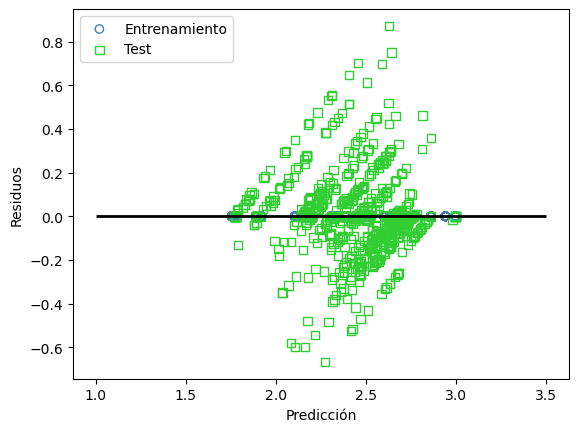

In [18]:
# Graficar datos
plt.scatter(Y_pred_train, Y_pred_train - Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_pred_test, Y_pred_test - Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

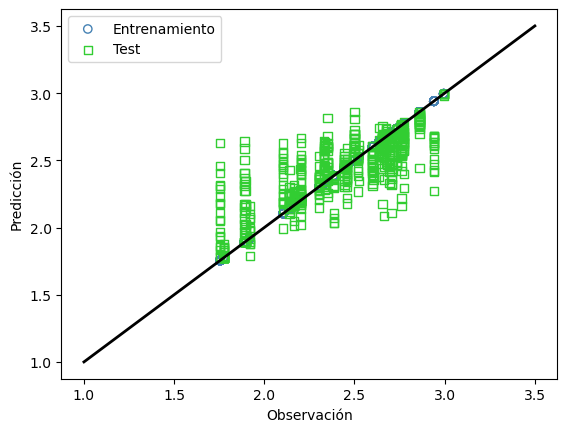

In [19]:
# Graficar datos
plt.scatter(Y_train, Y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_test, Y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color='black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()

## Multilayer Perceptron Regressor

In [20]:
# Entrenamiento de modelo
mlp = joblib.load('./modelo_mlp_pca2.pkl')

inicio = time.time()
mlp.fit(X_train_pca, Y_train)
fin = time.time()

print('Tiempo de entrenamiento: ', round(fin - inicio, 3), 's')

Tiempo de entrenamiento:  0.207 s


In [21]:
# Predecir datos
inicio = time.time()
Y_pred_train = mlp.predict(X_train_pca)
Y_pred_test = mlp.predict(X_test_pca)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.001 s


In [22]:
# Métricas de evaluación
E = mean_squared_error(Y_train, Y_pred_train)
r2 = r2_score(Y_train, Y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.058
R2:  0.46
Datos de test
Error cuadrático medio:  0.058
R2:  0.46


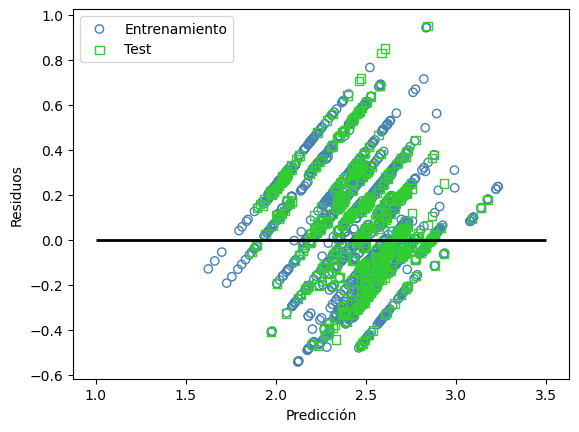

In [23]:
# Graficar datos
plt.scatter(Y_pred_train, Y_pred_train - Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_pred_test, Y_pred_test - Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

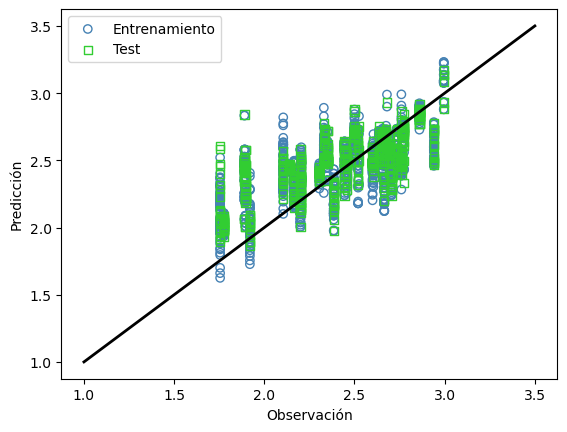

In [24]:
# Graficar datos
plt.scatter(Y_train, Y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(Y_test, Y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color='black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()